In [74]:
import numpy as np
from colorspacious import cspace_convert
from PIL import Image

from colorpalettes.from_image import image_colors

In [75]:
target_size = 500

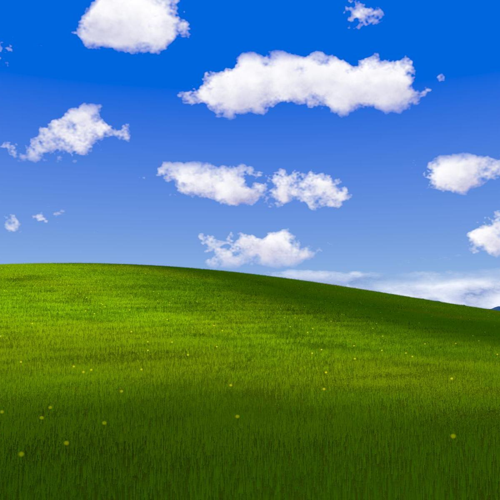

In [76]:
a = Image.open("data/bliss.jpg")
a = a.resize((int(target_size / a.height * a.width), target_size))
margin = (a.width - target_size) / 2
a = a.crop((margin, 0, a.width - margin, a.height))
a

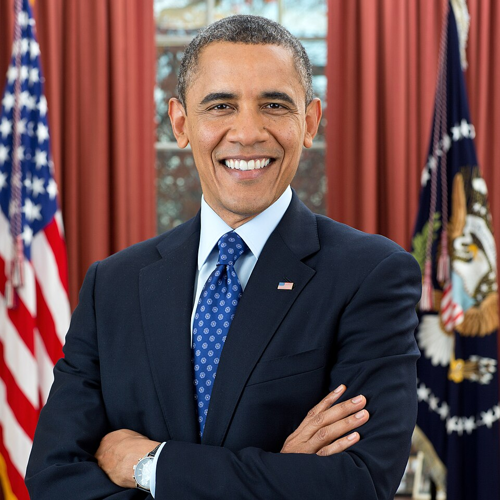

In [77]:
b = Image.open("data/obama.jpg")
b = b.resize((target_size, int(target_size * b.height / b.width)))
b = b.crop((0, 0, b.width, target_size))
b

In [78]:
apix = image_colors(a)
bpix = image_colors(b)

In [79]:
def blend(space: str, scheme: str) -> Image.Image:
    abl = cspace_convert(apix, "sRGB1", space)
    bbl = cspace_convert(bpix, "sRGB1", space)

    selected = [(abl if ch == "a" else bbl)[:, i] for i, ch in enumerate(scheme)]
    blend = np.vstack(selected).T
    res_pixels = cspace_convert(blend, space, "sRGB255")

    res_pixels_sq = np.array(res_pixels).reshape((target_size, target_size, 3))
    res_pixels_sq = (res_pixels_sq).astype(np.uint8)
    return Image.fromarray(res_pixels_sq)

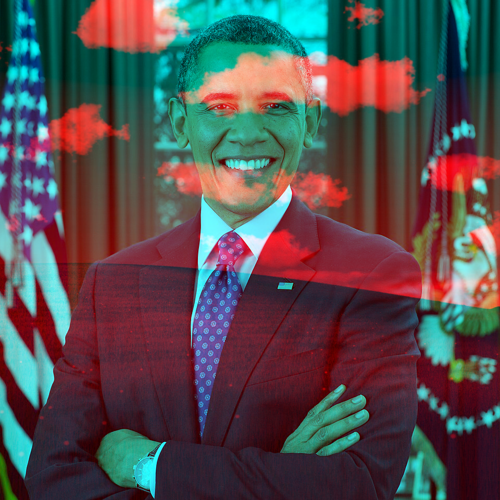

In [82]:
blend(space="sRGB1", scheme="abb")